In [646]:
import numpy as np
import matplotlib.pyplot as plt

In [647]:
lambd = 3.5 / 100         
l = 23.7 / 100      
h = 12.0 / 100       
er = 2.2                  
tgd = 2e-4                
d_avg = 2.3 / 100
d_max = 2.9 / 100     

gamma = 1 + (np.sqrt(er) - 1) * (d_avg / lambd)
if gamma > np.sqrt(er): gamma = np.sqrt(er)
alpha = (np.pi * np.sqrt(er) * tgd) / lambd

In [648]:
F1 = []
FC = []
FH = []

steps = np.arange(0.01, 90.01, 0.0005)
theta_rad = np.radians(steps)
    
for teta in theta_rad:
    psi = (np.pi * l / lambd) * (gamma - np.cos(teta))
    num_sq = 1 + np.exp(-2 * alpha * l) - 2 * np.exp(-alpha * l) * np.cos(2 * psi)
    den_sq = (alpha * l) ** 2 + (4 * psi ** 2)
    f_rod = np.sqrt(num_sq / den_sq)
        
    f1 = np.cos(teta) 
    fc = np.abs(np.cos((np.pi * h / lambd) * np.sin(teta)))
    res = f1 * fc * f_rod

    F1.append(f1)
    FC.append(fc)
    FH.append(res)

FH = np.array(FH) / np.max(FH)

for index, f in enumerate(FH):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]

In [649]:
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FH) - 1):
    if FH[i] < FH[i - 1] and FH[i] < FH[i + 1]:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

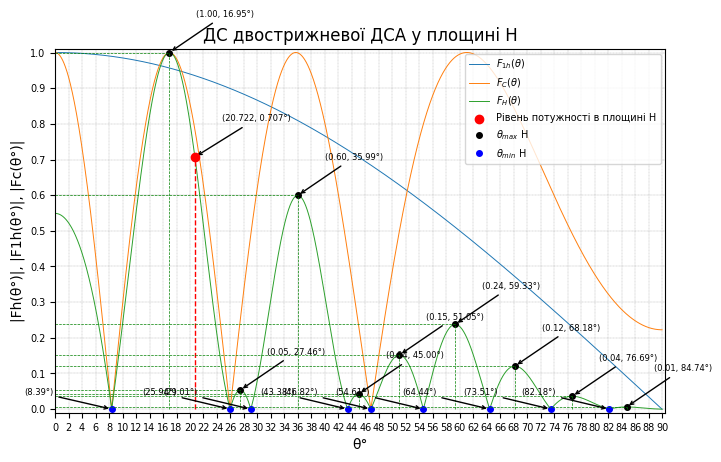

In [650]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС двострижневої ДСА у площині H")
ax.plot(steps, F1, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині H")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС двострижневої ДСА у площині H, лабораторна 3.jpg", dpi=600)
plt.show()

In [651]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 41.44°


In [652]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |8.39|  0  |
| 2 |25.94|  0  |
| 3 |29.01|  0  |
| 4 |43.38|  0  |
| 5 |46.82|  0  |
| 6 |54.61|  0  |
| 7 |64.44|  0  |
| 8 |73.51|  0  |
| 9 |82.18|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |16.95| 1.00|
| 2 |27.46| 0.05|
| 3 |35.99| 0.60|
| 4 |45.00| 0.04|
| 5 |51.05| 0.15|
| 6 |59.33| 0.24|
| 7 |68.18| 0.12|
| 8 |76.69| 0.04|
| 9 |84.74| 0.01|
-----------------


In [653]:
F1 = []
FC = []
FH = []

steps = np.arange(0.01, 90.01, 0.05)
theta_rad = np.radians(steps)
    
for teta in theta_rad:
    psi = (np.pi * l / lambd) * (gamma - np.cos(teta))
    num_sq = 1 + np.exp(-2 * alpha * l) - 2 * np.exp(-alpha * l) * np.cos(2 * psi)
    den_sq = (alpha * l) ** 2 + (4 * psi ** 2)
    f_rod = np.sqrt(num_sq / den_sq)
        
    f1 = np.cos(teta) ** 1.5
    fc = f_rod 
    res = f1 * fc

    F1.append(f1)
    FC.append(fc)
    FH.append(res)

FH = np.array(FH) / np.max(FH)

for index, f in enumerate(FH):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]

In [654]:
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FH) - 1):
    if FH[i] < FH[i - 1] and FH[i] < FH[i + 1]:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

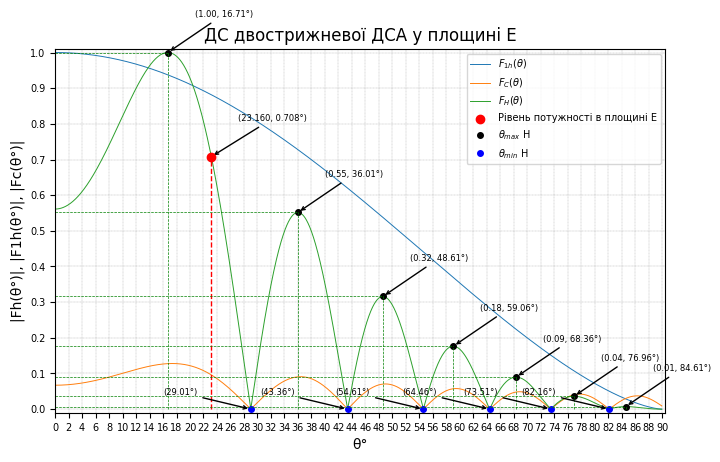

In [655]:
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС двострижневої ДСА у площині E")
ax.plot(steps, F1, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині E")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС двострижневої ДСА у площині E, лабораторна 4.jpg", dpi=600)
plt.show()

In [656]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 46.32°


In [657]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |29.01|  0  |
| 2 |43.36|  0  |
| 3 |54.61|  0  |
| 4 |64.46|  0  |
| 5 |73.51|  0  |
| 6 |82.16|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |16.71| 1.00|
| 2 |36.01| 0.55|
| 3 |48.61| 0.32|
| 4 |59.06| 0.18|
| 5 |68.36| 0.09|
| 6 |76.96| 0.04|
| 7 |84.61| 0.01|
-----------------
